# Simulación Monte Carlo — (Mundial 2026)

Este notebook recorre el flujo de [`src/simulation/monte_carlo.py`](../src/simulation/monte_carlo.py): carga del modelo y del JSON de grupos, snapshot de features as-of, tensor de probabilidades por duelo y simulación Monte Carlo del torneo (grupos + knockout con reglas FIFA).

**Prerrequisitos**

- Modelo entrenado: `models/final_xgboost.pkl` (`02_training.ipynb` o `python -m src.model.train`).
- Grupos: `data/external/world_cup_2026.json` (`sim_date`, `hosts`, 12 grupos).
- Histórico en `data/raw/` (p. ej. `international_results.csv`) para construir ELO y features as-of en la fecha de simulación.

**Rendimiento:** `ITERATIONS = 10_000` puede tardar varios minutos; para pruebas rápidas baja a `1_000` o `2_000` en la celda de configuración.

**Comando equivalente en CLI:** `python -m src.simulation.monte_carlo --iterations 10000 --groups data/external/world_cup_2026.json`

In [21]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.simulation.feature_provider import build_probability_tensor, validate_model_feature_order
from src.simulation.monte_carlo import _load_groups_and_snapshot, execute_monte_carlo, write_summary
from src.simulation.tournament_rules import GROUP_LETTERS, teams_in_order
from src.notebook_figures import save_notebook_figure
from src.utils import PROJECT_ROOT, REPORTS_DIR, set_seed, setup_logging

sns.set_theme(style="whitegrid")
setup_logging()

In [22]:
SEED = 42
# Para iteración rápida en Jupyter, prueba 1_000 o 2_000
ITERATIONS = 10_000

MODEL_PATH = PROJECT_ROOT / "models" / "final_xgboost.pkl"
GROUPS_PATH = PROJECT_ROOT / "data" / "external" / "world_cup_2026.json"
OUT_CSV = REPORTS_DIR / "monte_carlo_top5.csv"

if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"No existe el modelo: {MODEL_PATH}")
if not GROUPS_PATH.is_file():
    raise FileNotFoundError(f"No existe el JSON de grupos: {GROUPS_PATH}")

set_seed(SEED)
print("Modelo:", MODEL_PATH)
print("Grupos:", GROUPS_PATH)
print("Iteraciones:", ITERATIONS)

Modelo: C:\Users\echoe\Desktop\lab01\models\final_xgboost.pkl
Grupos: C:\Users\echoe\Desktop\lab01\data\external\world_cup_2026.json
Iteraciones: 10000


In [23]:
model = joblib.load(MODEL_PATH)
validate_model_feature_order(model)
print("Orden de features del modelo validado.")

2026-05-24 06:59:16 | WARNING | src.simulation.feature_provider | El modelo base no expone feature_names_in_; validación por n_features_in_ solamente.


Orden de features del modelo validado.


In [24]:
groups, snap, hosts, sim_date = _load_groups_and_snapshot(GROUPS_PATH, sim_date_override=None, seed=SEED)
print("sim_date:", sim_date)
print("hosts:", sorted(hosts))

grp_df = pd.DataFrame({g: groups[g] for g in GROUP_LETTERS}).T
grp_df.columns = [f"pos{i+1}" for i in range(grp_df.shape[1])]
display(grp_df)

2026-05-24 06:59:17 | WARNING | src.preprocessing | Equipos no mapeados (muestra hasta 40): ['saint_kitts_and_nevis', 'saint_lucia', 'saint_pierre_and_miquelon', 'saint_vincent_and_the_grenadines', 'sao_tome_and_principe', 'sapmi', 'sark', 'saugeais', 'sealand', 'seborga', 'seychelles', 'shetland', 'silesia', 'singapore', 'somaliland', 'south_ossetia', 'south_yemen', 'surrey', 'szekely_land', 'taiwan', 'tamil_eelam', 'tibet', 'ticino', 'turks_and_caicos_islands', 'two_sicilies', 'united_koreans_in_japan', 'united_states_virgin_islands', 'uzbekistan', 'vatican_city', 'vietnam_republic', 'wallis_islands_and_futuna', 'west_papua', 'western_armenia', 'western_australia', 'western_isles', 'western_sahara', 'yemen_dpr', 'ynys_mon', 'yorkshire', 'yoruba_nation'] | total claves únicas: 41


sim_date: 2026-06-11
hosts: ['CAN', 'MEX', 'USA']


,pos1,pos2,pos3,pos4
A,USA,CAN,MEX,ALB
B,AND,ARM,AUS,AZE
C,BER,BFA,BGR,BIH
D,CAY,CGO,CHL,CHN
E,CIV,CMR,COD,CRI
F,CYP,CZE,DZA,EGY
G,ESP,FIN,FRO,GAB
H,GEO,GHA,GUA,GUM
I,HND,IRN,ISL,JAM
J,JPN,KOR,KWT,LBY


In [25]:
teams = teams_in_order(groups)
team_to_idx = {t: i for i, t in enumerate(teams)}
P = build_probability_tensor(teams, snap, model, hosts)
print("Shape tensor P (n_teams, n_teams, 3):", P.shape)
print(
    "Convención (igual que simulate_elimination_winner): "
    "P[ia, ib, 0] = P(gana el equipo ia); P[..., 1] = empate; P[..., 2] = P(gana ib)."
)

for ta, tb in [(teams[0], teams[1]), (teams[0], teams[2]), (teams[5], teams[10])]:
    ia, ib = team_to_idx[ta], team_to_idx[tb]
    pr = P[ia, ib]
    s = pr[0] + pr[1] + pr[2]
    print(f"\n{ta} vs {tb}: P({ta})={pr[0]/s:.4f}, P(empate)={pr[1]/s:.4f}, P({tb})={pr[2]/s:.4f}")

Shape tensor P (n_teams, n_teams, 3): (48, 48, 3)
Convención (igual que simulate_elimination_winner): P[ia, ib, 0] = P(gana el equipo ia); P[..., 1] = empate; P[..., 2] = P(gana ib).

USA vs CAN: P(USA)=0.2850, P(empate)=0.2797, P(CAN)=0.4353

USA vs MEX: P(USA)=0.1532, P(empate)=0.2662, P(MEX)=0.5806

ARM vs BGR: P(ARM)=0.2546, P(empate)=0.2444, P(BGR)=0.5010


In [26]:
df = execute_monte_carlo(groups, snap, model, hosts, iterations=ITERATIONS, seed=SEED)
display(df.head(15))

2026-05-24 07:06:12 | WARNING | src.simulation.feature_provider | El modelo base no expone feature_names_in_; validación por n_features_in_ solamente.


,Selección,Victorias_Titulo,Probabilidad_Campeón,Probabilidad_Final,Probabilidad_Semi,IC95_Campeon_Lo,IC95_Campeon_Hi,IC95_Final_Lo,IC95_Final_Hi,IC95_Semi_Lo,IC95_Semi_Hi
0,ESP,5160,0.5160,0.6045,0.6984,0.506201,0.525787,0.594878,0.614042,0.689330,0.707318
1,NOR,1074,0.1074,0.2554,0.4166,0.101481,0.113620,0.246948,0.264040,0.406971,0.426293
2,JPN,751,0.0751,0.2016,0.3455,0.070096,0.080430,0.193852,0.209577,0.336241,0.354878
3,MAR,702,0.0702,0.2184,0.3728,0.065356,0.075374,0.210411,0.226605,0.363373,0.382325
4,MEX,551,0.0551,0.1461,0.3535,0.050796,0.059745,0.139313,0.153159,0.344188,0.362925
5,CAN,426,0.0426,0.1016,0.2981,0.038814,0.046737,0.095831,0.107675,0.289213,0.307142
6,AUS,282,0.0282,0.0958,0.2028,0.025132,0.031630,0.090186,0.101725,0.195034,0.210794
7,NGA,267,0.0267,0.0792,0.1668,0.023718,0.030046,0.074067,0.084656,0.159621,0.174234
8,IRN,190,0.0190,0.0550,0.2105,0.016503,0.021866,0.050700,0.059642,0.202622,0.218601
9,KOR,141,0.0141,0.0502,0.1155,0.011969,0.016605,0.046090,0.054655,0.109382,0.121913


Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\03_simulation\01_champion_probability_top15_wilson_ci.png


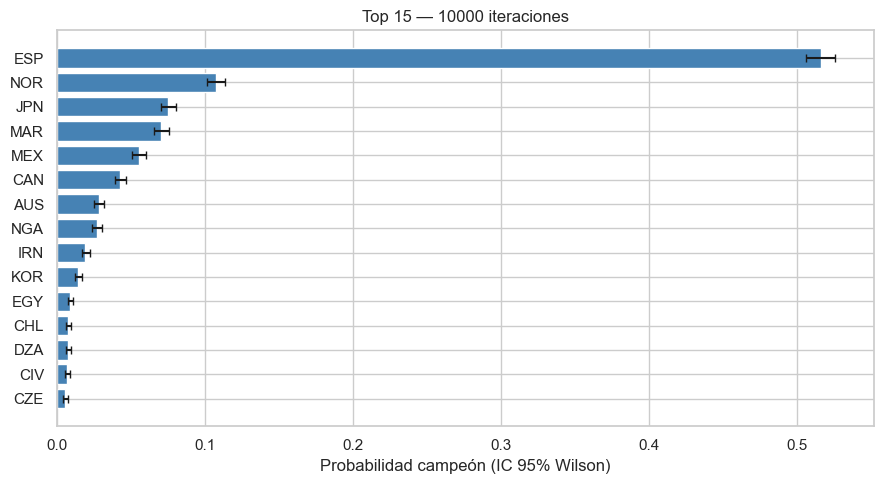

In [27]:
top_n = 15
sub = df.head(top_n).copy()
y_pos = np.arange(len(sub))
err_lo = sub["Probabilidad_Campeón"] - sub["IC95_Campeon_Lo"]
err_hi = sub["IC95_Campeon_Hi"] - sub["Probabilidad_Campeón"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y_pos, sub["Probabilidad_Campeón"], xerr=[err_lo, err_hi], color="steelblue", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(sub["Selección"])
ax.invert_yaxis()
ax.set_xlabel("Probabilidad campeón (IC 95% Wilson)")
ax.set_title(f"Top {top_n} — {ITERATIONS} iteraciones")
plt.tight_layout()
path = save_notebook_figure(fig, notebook="03_simulation", index=1, name="champion_probability_top15_wilson_ci")
print("Figura guardada:", path.resolve())
plt.show()

Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\03_simulation\02_final_probability_top10.png


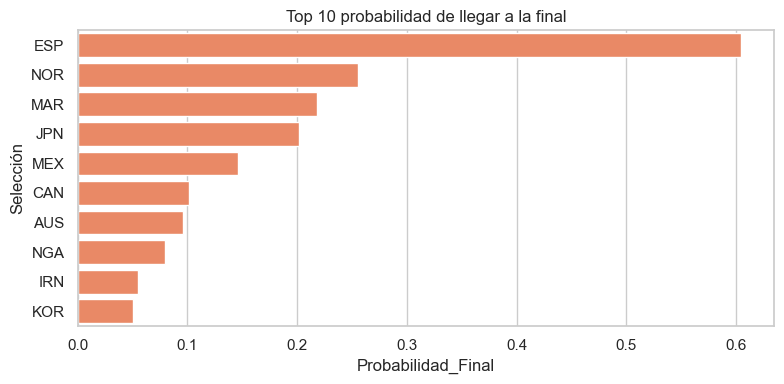

In [28]:
sub_f = df.sort_values("Probabilidad_Final", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=sub_f, y="Selección", x="Probabilidad_Final", ax=ax, color="coral", order=sub_f["Selección"])
ax.set_title("Top 10 probabilidad de llegar a la final")
plt.tight_layout()
path = save_notebook_figure(fig, notebook="03_simulation", index=2, name="final_probability_top10")
print("Figura guardada:", path.resolve())
plt.show()

In [29]:
show_cols = [
    "Selección",
    "Victorias_Titulo",
    "Probabilidad_Campeón",
    "Probabilidad_Final",
    "Probabilidad_Semi",
]
display(
    df[show_cols]
    .head(20)
    .style.format(
        {
            "Probabilidad_Campeón": "{:.2%}",
            "Probabilidad_Final": "{:.2%}",
            "Probabilidad_Semi": "{:.2%}",
        }
    )
)

,Selección,Victorias_Titulo,Probabilidad_Campeón,Probabilidad_Final,Probabilidad_Semi
0,ESP,5160,51.60%,60.45%,69.84%
1,NOR,1074,10.74%,25.54%,41.66%
2,JPN,751,7.51%,20.16%,34.55%
3,MAR,702,7.02%,21.84%,37.28%
4,MEX,551,5.51%,14.61%,35.35%
5,CAN,426,4.26%,10.16%,29.81%
6,AUS,282,2.82%,9.58%,20.28%
7,NGA,267,2.67%,7.92%,16.68%
8,IRN,190,1.90%,5.50%,21.05%
9,KOR,141,1.41%,5.02%,11.55%


In [30]:
SUMMARY_PATH = REPORTS_DIR / "monte_carlo_summary.txt"

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)
write_summary(
    SUMMARY_PATH,
    iterations=ITERATIONS,
    seed=SEED,
    model_path=MODEL_PATH,
    groups_path=GROUPS_PATH,
    sim_date=sim_date,
    df=df,
    groups=groups,
)
print("CSV guardado:", OUT_CSV.resolve())
print("Resumen:", SUMMARY_PATH.resolve())
print("\nTop 5 (como en CLI):")
print(df.head(5).to_string(index=False))

2026-05-24 07:07:23 | INFO | src.simulation.monte_carlo | Resumen escrito en C:\Users\echoe\Desktop\lab01\reports\monte_carlo_summary.txt


CSV guardado: C:\Users\echoe\Desktop\lab01\reports\monte_carlo_top5.csv
Resumen: C:\Users\echoe\Desktop\lab01\reports\monte_carlo_summary.txt

Top 5 (como en CLI):
Selección  Victorias_Titulo  Probabilidad_Campeón  Probabilidad_Final  Probabilidad_Semi  IC95_Campeon_Lo  IC95_Campeon_Hi  IC95_Final_Lo  IC95_Final_Hi  IC95_Semi_Lo  IC95_Semi_Hi
      ESP              5160                0.5160              0.6045             0.6984         0.506201         0.525787       0.594878       0.614042      0.689330      0.707318
      NOR              1074                0.1074              0.2554             0.4166         0.101481         0.113620       0.246948       0.264040      0.406971      0.426293
      JPN               751                0.0751              0.2016             0.3455         0.070096         0.080430       0.193852       0.209577      0.336241      0.354878
      MAR               702                0.0702              0.2184             0.3728         0.065356       

La celda anterior escribe `reports/monte_carlo_top5.csv` (tabla completa ordenada) y `reports/monte_carlo_summary.txt` (mismo formato que la CLI). Las celdas con gráficos guardan PNG en `reports/figures/03_simulation/`.